## German Apartment Rent Prediction


### Business Problem


The problem is that property owners or landlords list their apartments for rent, either underestimating or overesitamting the price. 
This project focuses on creating an ML pipeline that can predict property rent fairly,based on its features. 

This matters because if property owners or are allowed to overestiamte rent prices on the platform, it causes a domino effect: potential customers get dissatisfied and leave, the platform's reputation gets worse, and that leads to less revenune and profit. Addiontally, newcomers could also be unware that they are being overcharged monthly.

Data source: https://www.kaggle.com/datasets/corrieaar/apartment-rental-offers-in-germany


In [1]:
import pandas as pd
import numpy as np

import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

import joblib

import sklearn
from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, TargetEncoder

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

from sklearn.model_selection import GridSearchCV
from sklearn.cluster import KMeans

### Data Loading & Explorlation

In [2]:
df=pd.read_csv('immo_data.csv')
print(f"The shape of the dataframe is: {df.shape}")
df.info()

The shape of the dataframe is: (268850, 49)
<class 'pandas.DataFrame'>
RangeIndex: 268850 entries, 0 to 268849
Data columns (total 49 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   regio1                    268850 non-null  str    
 1   serviceCharge             261941 non-null  float64
 2   heatingType               223994 non-null  str    
 3   telekomTvOffer            236231 non-null  str    
 4   telekomHybridUploadSpeed  45020 non-null   float64
 5   newlyConst                268850 non-null  bool   
 6   balcony                   268850 non-null  bool   
 7   picturecount              268850 non-null  int64  
 8   pricetrend                267018 non-null  float64
 9   telekomUploadSpeed        235492 non-null  float64
 10  totalRent                 228333 non-null  float64
 11  yearConstructed           211805 non-null  float64
 12  scoutId                   268850 non-null  int64  
 13  noParkSpace

In [3]:
def display_columns_in_group(dataframe,group_size):
    display_five_col_dict={}
    x=0
    for name, values in dataframe.items():
        x+=1
        display_five_col_dict[name]=[values[0],values[1],values[2],values[3],values[4]]
        display_five_col_dict=pd.DataFrame(display_five_col_dict)
        if x%group_size==0:
            print(display_five_col_dict)
            display_five_col_dict={}
        else:
            continue

display_columns_in_group(df,7)

                regio1  serviceCharge                     heatingType  \
0  Nordrhein_Westfalen         245.00                 central_heating   
1      Rheinland_Pfalz         134.00  self_contained_central_heating   
2              Sachsen         255.00                   floor_heating   
3              Sachsen          58.15                district_heating   
4               Bremen         138.00  self_contained_central_heating   

  telekomTvOffer  telekomHybridUploadSpeed  newlyConst  balcony  
0  ONE_YEAR_FREE                       NaN       False    False  
1  ONE_YEAR_FREE                       NaN       False     True  
2  ONE_YEAR_FREE                      10.0        True     True  
3  ONE_YEAR_FREE                       NaN       False     True  
4            NaN                       NaN       False     True  
   picturecount  pricetrend  telekomUploadSpeed  totalRent  yearConstructed  \
0             6        4.62                10.0      840.0           1965.0   
1      

In [4]:
print(f"The total number of duplicated rows: {df.duplicated().sum()}")
print("-"*60)
print("The precentage of missing values per column:")
df.isnull().sum()/len(df)*100 


The total number of duplicated rows: 0
------------------------------------------------------------
The precentage of missing values per column:


regio1                       0.000000
serviceCharge                2.569834
heatingType                 16.684397
telekomTvOffer              12.132788
telekomHybridUploadSpeed    83.254603
newlyConst                   0.000000
balcony                      0.000000
picturecount                 0.000000
pricetrend                   0.681421
telekomUploadSpeed          12.407662
totalRent                   15.070485
yearConstructed             21.218151
scoutId                      0.000000
noParkSpaces                65.388879
firingTypes                 21.188023
hasKitchen                   0.000000
geo_bln                      0.000000
cellar                       0.000000
yearConstructedRange        21.218151
baseRent                     0.000000
houseNumber                 26.415473
livingSpace                  0.000000
geo_krs                      0.000000
condition                   25.474800
interiorQual                41.906267
petsAllowed                 42.615957
street      

In [5]:
def count_nunuique_for_each_col(columns):
    x=0
    last_column=columns[-1]
    
    for column in columns:
        x+=1
        print(f"The number of unique values for {column}: {df[column].nunique()}")
        if x%3==0 and column==last_column:
            pass 
        elif x%3==0:
            print("Continued"+"."*35+">")
           

columns_list=["regio1","geo_bln","typeOfFlat","heatingType","firingTypes"
              ,"petsAllowed","geo_krs","regio2","condition",
              "yearConstructed"]

count_nunuique_for_each_col(columns_list)


The number of unique values for regio1: 16
The number of unique values for geo_bln: 16
The number of unique values for typeOfFlat: 10
Continued...................................>
The number of unique values for heatingType: 13
The number of unique values for firingTypes: 132
The number of unique values for petsAllowed: 3
Continued...................................>
The number of unique values for geo_krs: 419
The number of unique values for regio2: 419
The number of unique values for condition: 10
Continued...................................>
The number of unique values for yearConstructed: 465


In [6]:
def are_the_two_columns_equal(column_one,column_two):
    print(f" {column_one} has the same values as {column_two}: {df[column_one].equals(df[column_two])}")

are_the_two_columns_equal('regio1','geo_bln')
are_the_two_columns_equal('regio2','geo_krs')


 regio1 has the same values as geo_bln: True
 regio2 has the same values as geo_krs: True


In [7]:
def display_value_count_for_columns(columns):
    last_col=columns[-1]
    for column in columns:
        if last_col==column: 
            print(f"Column Name: {df[column].value_counts()}")
        else:
            print(f"Column Name: {df[column].value_counts()}")
            print("."*40)

        
columns_list=["typeOfFlat","geo_plz",
              "yearConstructed","condition"]
display_value_count_for_columns(columns_list)

Column Name: typeOfFlat
apartment              131522
roof_storey             34787
ground_floor            31538
other                    9519
maisonette               9319
raised_ground_floor      5628
penthouse                3568
terraced_flat            3385
half_basement            2013
loft                      957
Name: count, dtype: int64
........................................
Column Name: geo_plz
9130     2008
9126     1994
9131     1649
9112     1626
9113     1416
         ... 
79291       1
7616        1
74214       1
84437       1
82390       1
Name: count, Length: 7634, dtype: int64
........................................
Column Name: yearConstructed
2019.0    10959
1900.0    10356
2018.0     8759
1995.0     4387
1996.0     4339
          ...  
1621.0        1
1440.0        1
1601.0        1
1796.0        1
1472.0        1
Name: count, Length: 465, dtype: int64
........................................
Column Name: condition
well_kept                             66591
r

### data 

In [8]:
df=df[df['condition']!='ripe_for_demolition']
# Drops unwanted columns
df=df.drop(columns=["regio1","serviceCharge","telekomTvOffer","telekomUploadSpeed","picturecount","houseNumber","yearConstructedRange","scoutId","baseRent"
                    ,"street","geo_krs","streetPlain","baseRentRange","telekomHybridUploadSpeed","noParkSpaces","firingTypes","geo_bln","numberOfFloors","regio3"
                    ,"description", "facilities","heatingCosts","energyEfficiencyClass","lastRefurbish","electricityBasePrice","electricityKwhPrice"
                    ,"date","noRoomsRange","livingSpaceRange"])

df= df.dropna(subset=["pricetrend","totalRent"])

convert_bolColumns_to_str_dict = {"newlyConst": str, "balcony": str,"hasKitchen":str,"cellar":str,"lift":str,"garden":str}
df=df.astype(convert_bolColumns_to_str_dict)

df=df.rename(columns={"regio2": "city"})

In [9]:

df['hasKitchen'].value_counts()

hasKitchen
False    147785
True      78935
Name: count, dtype: int64

In [10]:
# Returns a Statistical summary
df.describe()

,pricetrend,totalRent,yearConstructed,livingSpace,geo_plz,noRooms,thermalChar,floor
count,226720.000000,2.267200e+05,177722.000000,226720.000000,226720.000000,226720.000000,133635.000000,186617.000000
mean,3.394360,8.999483e+02,1965.545824,73.618409,36462.568313,2.618458,114.102661,2.128916
std,2.002072,3.335630e+04,47.859076,274.717742,27989.000424,1.730765,59.880213,3.233101
min,-12.330000,0.000000e+00,1000.000000,0.000000,852.000000,1.000000,0.100000,-1.000000
25%,1.960000,4.690000e+02,1940.000000,53.970000,9119.000000,2.000000,79.000000,1.000000
50%,3.390000,6.490000e+02,1972.000000,66.960000,37520.000000,3.000000,106.100000,2.000000
75%,4.600000,9.800000e+02,1996.000000,85.970000,56068.000000,3.000000,139.000000,3.000000
max,14.920000,1.575154e+07,2090.000000,111111.000000,99998.000000,560.000000,1983.000000,999.000000


In [11]:
# Removing outliers 
df=df[df['floor']<=21]
df=df[df['noRooms']<=12]
df=df[(df['livingSpace']>=6) &(df['livingSpace']<=800)]
df=df[(df['yearConstructed']>=1624)&(df['yearConstructed']<=2019)]
df=df[(df['totalRent']>=200) &(df['totalRent']<=4000)]
df=df[(df['thermalChar']>=10) &(df['thermalChar']<=400)]



df.describe()

,pricetrend,totalRent,yearConstructed,livingSpace,geo_plz,noRooms,thermalChar,floor
count,103849.000000,103849.000000,103849.000000,103849.000000,103849.000000,103849.000000,103849.000000,103849.000000
mean,3.226561,747.624525,1966.158807,69.412154,32746.565147,2.579242,112.537272,2.225395
std,2.075176,473.605165,36.797464,26.963134,27054.682956,0.912023,49.127207,1.762481
min,-12.330000,200.000000,1633.000000,8.000000,1057.000000,1.000000,10.000000,-1.000000
25%,1.790000,446.000000,1951.000000,53.090000,8523.000000,2.000000,79.200000,1.000000
50%,3.170000,590.000000,1971.000000,64.500000,28201.000000,3.000000,105.200000,2.000000
75%,4.410000,890.000000,1994.000000,80.000000,47623.000000,3.000000,137.900000,3.000000
max,12.870000,4000.000000,2019.000000,482.000000,99994.000000,12.000000,400.000000,21.000000


In [12]:
df_totalRent = df['totalRent']
fig = px.histogram(df_totalRent, x="totalRent")

fig.update_layout(
    height=800,
    title_text='Histogram of Total Rent'
)
fig.show() 

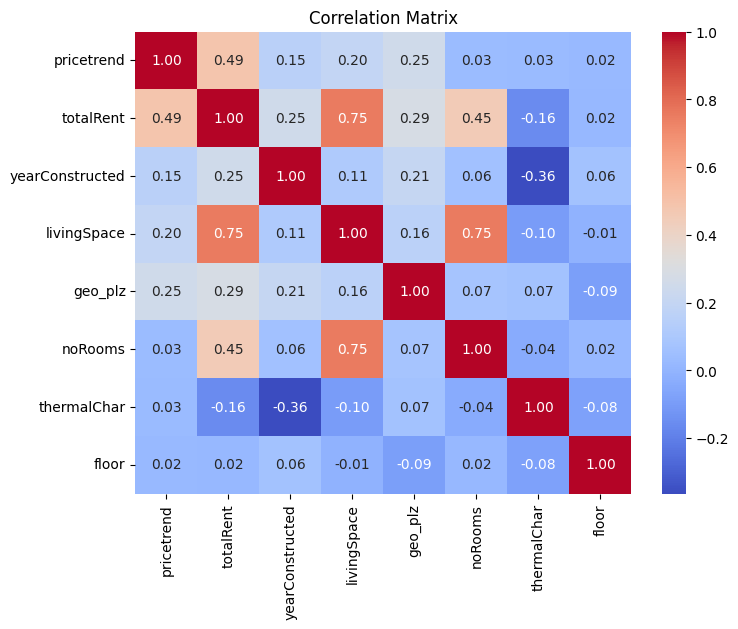

In [13]:
numerical_columns_df = df.select_dtypes(include=['int64', 'float64'])

correlation_matrix = numerical_columns_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Correlation Matrix")
plt.show()

In [14]:

fig = px.scatter(df, x="noRooms", y="livingSpace",color="noRooms")

fig.update_traces(textposition='top center')

fig.update_layout(
    height=800,
    title_text='Number of Rooms vs Living Space'
)
fig.show()

In [15]:
roomNumbers_list_one=[x+0.5 for x in range(1,12)]
roomNumbers_list_two=[x for x in range(1,13)]

room_numbers_list=roomNumbers_list_one+roomNumbers_list_two

df= df[df['noRooms'].isin(room_numbers_list)]


df['SizePerRoom']= df['livingSpace']/df['noRooms']
df=df[((df['SizePerRoom']>=6) &(df['SizePerRoom']<=60))]

fig = px.scatter(df, x="noRooms", y="livingSpace",color="noRooms")
fig.update_layout(
    height=800,
    title_text='Number of Rooms vs Living Space (after removing outliers and unrealistic values)'
    )

fig.update_traces(textposition='top center')


### Train Test Split 

In [16]:
X=df.copy()
y=df["totalRent"]

X_train, X_test, y_train, y_test = train_test_split(X,y,random_state=42,train_size=0.8,shuffle=True)

X_train=X_train.drop(columns=["totalRent"])
X_test=X_test.drop(columns=["totalRent"])


X_train.head()

,heatingType,newlyConst,balcony,pricetrend,yearConstructed,hasKitchen,cellar,livingSpace,condition,interiorQual,petsAllowed,lift,typeOfFlat,geo_plz,noRooms,thermalChar,floor,garden,city,SizePerRoom
110823,NaN,False,True,1.66,1961.0,False,True,66.38,NaN,NaN,NaN,False,NaN,58089,3.0,142.7,4.0,False,Hagen,22.126667
213044,central_heating,False,False,8.28,1902.0,False,False,55.00,well_kept,normal,NaN,False,apartment,10553,2.0,120.0,3.0,False,Berlin,27.500000
184265,central_heating,False,False,4.47,1890.0,False,False,29.00,modernized,normal,NaN,False,apartment,68159,2.0,143.9,4.0,False,Mannheim,14.500000
204639,district_heating,False,True,4.00,1974.0,True,True,116.00,modernized,sophisticated,negotiable,True,apartment,41460,4.0,164.0,13.0,False,Neuss_Rhein_Kreis,29.000000
160598,central_heating,False,False,2.97,1991.0,False,True,39.12,fully_renovated,normal,negotiable,False,ground_floor,1896,2.0,126.0,0.0,True,Bautzen_Kreis,19.560000


In [17]:
# Replacing Missing values
def fillna_for_columns(df,columns,value):
    for column in columns:
        df[column]=df[column].fillna(value)
fillna_for_columns(X_train,["heatingType","condition","interiorQual","petsAllowed"],"unknown")

X_train['yearConstructed']=X_train['yearConstructed'].fillna(
X_train['yearConstructed'].median())

X_train.loc[(X_train["thermalChar"].isnull()),'thermalChar']=X_train['thermalChar'].median()

X_train=X_train[~((X_train['typeOfFlat'].isnull())&(X_train['floor'].isnull()))]

X_train.loc[(X_train['typeOfFlat']=='ground_floor')&(X_train["floor"].isnull()),'floor']=0.0
X_train.loc[(X_train['typeOfFlat']=='raised_ground_floor')&(X_train["floor"].isnull()),'floor']=1.0

X_train.loc[(X_train['typeOfFlat']=='penthouse')&(X_train["floor"].isnull()),'floor']=X_train[X_train['typeOfFlat']=='penthouse']['floor'].median()
X_train.loc[(X_train['typeOfFlat']=='other')&(X_train["floor"].isnull()),'floor']=X_train[X_train['typeOfFlat']=='other']['floor'].median()
X_train.loc[(X_train['typeOfFlat']=='terraced_flat')&(X_train["floor"].isnull()),'floor']=X_train[X_train['typeOfFlat']=='terraced_flat']['floor'].median()
X_train.loc[(X_train['typeOfFlat']=='roof_storey')&(X_train["floor"].isnull()),'floor']=X_train[X_train['typeOfFlat']=='roof_storey']['floor'].median()

X_train.loc[(X_train['typeOfFlat']=='apartment')&(X_train["floor"].isnull()),'floor']=X_train[X_train['typeOfFlat']=='apartment']['floor'].median()
X_train.loc[(X_train['typeOfFlat']=='half_basement')&(X_train["floor"].isnull()),'floor']=X_train[X_train['typeOfFlat']=='half_basement']['floor'].median()
X_train.loc[(X_train['typeOfFlat']=='loft')&(X_train["floor"].isnull()),'floor']=X_train[X_train['typeOfFlat']=='loft']['floor'].median()

X_train.loc[(X_train['typeOfFlat']=='maisonette')&(X_train["floor"].isnull()),'floor']=2.0

fillna_for_columns(X_train,['typeOfFlat'],"unknown")

X_train.isnull().sum()

heatingType        0
newlyConst         0
balcony            0
pricetrend         0
yearConstructed    0
hasKitchen         0
cellar             0
livingSpace        0
condition          0
interiorQual       0
petsAllowed        0
lift               0
typeOfFlat         0
geo_plz            0
noRooms            0
thermalChar        0
floor              0
garden             0
city               0
SizePerRoom        0
dtype: int64

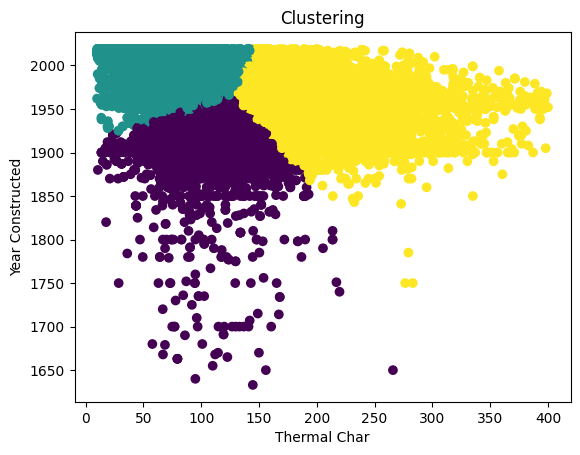

In [18]:

y_pred = KMeans(n_clusters=3,random_state=42).fit_predict(X_train[['thermalChar','yearConstructed']]
    
)
plt.scatter(x=X_train['thermalChar'],y=X_train['yearConstructed'], c=y_pred)
plt.title("Clustering")
plt.xlabel("Thermal Char")
plt.ylabel("Year Constructed")
plt.show()

### Data Preprocessing 

In [19]:
numerical_features =['pricetrend','yearConstructed','livingSpace','geo_plz'
                     , 'noRooms','thermalChar', 'floor', 'SizePerRoom']

numeric_transformer = Pipeline(
    steps=[("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]
)
categorical_features = ['heatingType', 'newlyConst', 'balcony', 
       'hasKitchen', 'cellar', 'condition', 'interiorQual',
       'petsAllowed', 'lift', 'typeOfFlat', 'garden']

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant",fill_value='unknown')),("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)
categorical_target_features=['city']

categorical_target_transformer = Pipeline(
    steps=[("target", TargetEncoder())
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features),
        ("cat_target",categorical_target_transformer,categorical_target_features)
    ]
)

### Linear Regression


In [20]:
liner_reg=clf = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("reg",LinearRegression()),
    ]
)

liner_reg.fit(X_train,y_train)

y_pred = liner_reg.predict(X_test)

linerReg_mae= mean_absolute_error(y_test,y_pred)
linearReg_Rmse=root_mean_squared_error(y_test,y_pred)
linearReg_R_squared_score=r2_score(y_test,y_pred)



### Knn

In [21]:
knn_reg=clf = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("reg",KNeighborsRegressor()),
    ]
)

knn_reg.fit(X_train,y_train)

y_pred = knn_reg.predict(X_test)

KnnReg_mae= mean_absolute_error(y_test,y_pred)
KnnReg_Rmse=root_mean_squared_error(y_test,y_pred)
KnnReg_R_squared_score=r2_score(y_test,y_pred)


### Random Forest

In [22]:
RandomForest_reg=clf = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("reg",RandomForestRegressor(random_state=42,n_jobs=1)),
    ]
)

RandomForest_reg.fit(X_train,y_train)

y_pred = RandomForest_reg.predict(X_test)

RandomForest_reg_mae= mean_absolute_error(y_test,y_pred)
RandomForest_reg_Rmse=root_mean_squared_error(y_test,y_pred)
RandomForest_reg_R_squared_score=r2_score(y_test,y_pred)


### SVR

In [23]:
SVR_reg=clf = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("reg",SVR(kernel='rbf')),
    ]
)

SVR_reg.fit(X_train,y_train)

y_pred = SVR_reg.predict(X_test)

SVR_reg_mae= mean_absolute_error(y_test,y_pred)
SVR_reg_Rmse=root_mean_squared_error(y_test,y_pred)
SVR_reg_R_squared_score=r2_score(y_test,y_pred)

### Model Evaluation Results & Comparison

In [24]:
model_scores = pd.DataFrame({"Model":["Linear Regression","Knn","Random_Forest","Svr"],
               "Mae_Score":[linerReg_mae,KnnReg_mae,RandomForest_reg_mae,SVR_reg_mae],
               "Rmse_Score":[linearReg_Rmse,KnnReg_Rmse,RandomForest_reg_Rmse,SVR_reg_Rmse],
               "R_Squared_Score": [linearReg_R_squared_score,KnnReg_R_squared_score,RandomForest_reg_R_squared_score,SVR_reg_R_squared_score]})


# Sorts the Dataframe by the lowest Rmse score to the highest 
model_scores_sorted= model_scores.sort_values(by='Rmse_Score', ascending=True)
model_scores_sorted.head()

,Model,Mae_Score,Rmse_Score,R_Squared_Score
2,Random_Forest,75.995522,132.836803,0.919740
0,Linear Regression,115.604308,180.718277,0.851453
1,Knn,113.908772,184.991763,0.844344
3,Svr,218.134486,363.033802,0.400548


In [25]:
param_grid = {
    'reg__n_estimators': [100,150,200],
    'reg__max_features': [0.25, 0.5,1],
    'reg__max_depth':  [5,10,15] 
}

grid_search = GridSearchCV(RandomForest_reg, param_grid,cv=5,n_jobs=1,verbose=1)
grid_search.fit(X_train, y_train)
print("The best parameter is: ",grid_search.best_params_)
print("The best score is:",grid_search.best_score_)

Fitting 5 folds for each of 27 candidates, totalling 135 fits
The best parameter is:  {'reg__max_depth': 15, 'reg__max_features': 0.5, 'reg__n_estimators': 200}
The best score is: 0.9185021010462122


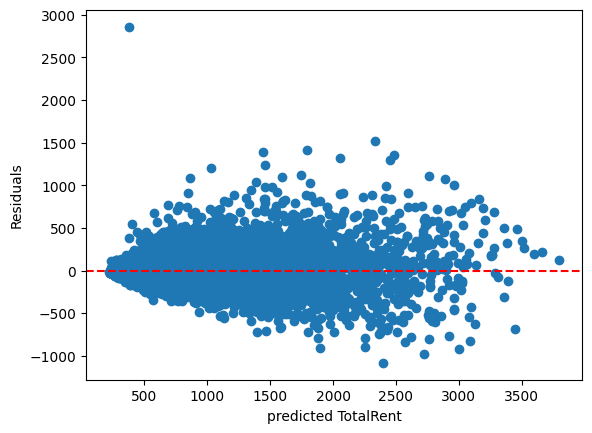

In [26]:
best_model=grid_search.best_estimator_

test_data_pred= best_model.predict(X_test)
residual = y_test - test_data_pred

plt.scatter(test_data_pred, residual)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("predicted TotalRent")
plt.ylabel("Residuals")
plt.show()


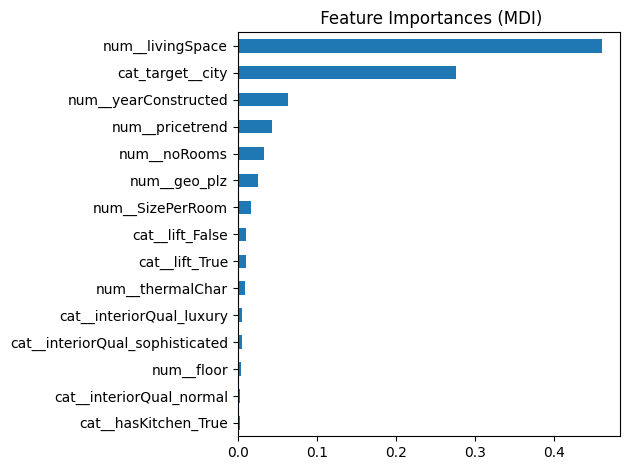

In [27]:

feature_names = best_model[:-1].get_feature_names_out()

mdi_importances = pd.Series(
    best_model[-1].feature_importances_, index=feature_names
).sort_values(ascending=True).tail(15)

ax = mdi_importances.plot.barh()
ax.set_title(" Feature Importances (MDI)")
ax.figure.tight_layout()



In [28]:
sample_data= pd.DataFrame ({'heatingType':['central_heating'], 'newlyConst':['False'], 'balcony':['True'], 'pricetrend':[2], 'yearConstructed':[2010],
       'hasKitchen':['True'], 'cellar':['True'], 'livingSpace':[30], 'condition':['well_kept'], 'interiorQual':['normal'],
       'petsAllowed':['Yes'], 'lift':['True'], 'typeOfFlat':['ground_floor'], 'geo_plz':[44269], 'noRooms':[2],
       'thermalChar':[100], 'floor':[2], 'noRoomsRange':[2], 'garden':['False'],
       'SizePerRoom':[8],'city':['Dortmund']
    
})


Y_pred = best_model.predict(sample_data)
print("Prediction: ",Y_pred)

Prediction:  [443.07938654]


In [ ]:
joblib.dump(best_model, 'best_model_compressedd.joblib',compress=9)
X_train.to_csv('train_data.csv')